# Layout Comparison: NetworkX vs NodeSubstrates

This notebook demonstrates how NodeSubstrates preserves the NetworkX force-directed layout
while adding the ability to create semantic substrates for focused analysis.

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
from node_substrates import NodeSubstratesWidget

## 1. Create Sample Graph

We'll use the Karate Club graph - a well-known social network with community structure.

In [2]:
# Create the Karate Club graph
G = nx.karate_club_graph()

# Add node attributes for analysis
for node in G.nodes():
    G.nodes[node]['degree'] = G.degree(node)
    G.nodes[node]['clustering'] = nx.clustering(G, node)
    G.nodes[node]['betweenness'] = nx.betweenness_centrality(G)[node]
    G.nodes[node]['closeness'] = nx.closeness_centrality(G)[node]

print(f"Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print(f"Node attributes: {list(G.nodes[0].keys())}")

Graph: 34 nodes, 78 edges
Node attributes: ['club', 'degree', 'clustering', 'betweenness', 'closeness']


## 2. NetworkX Standard Visualization

This is the traditional force-directed layout using NetworkX and matplotlib.

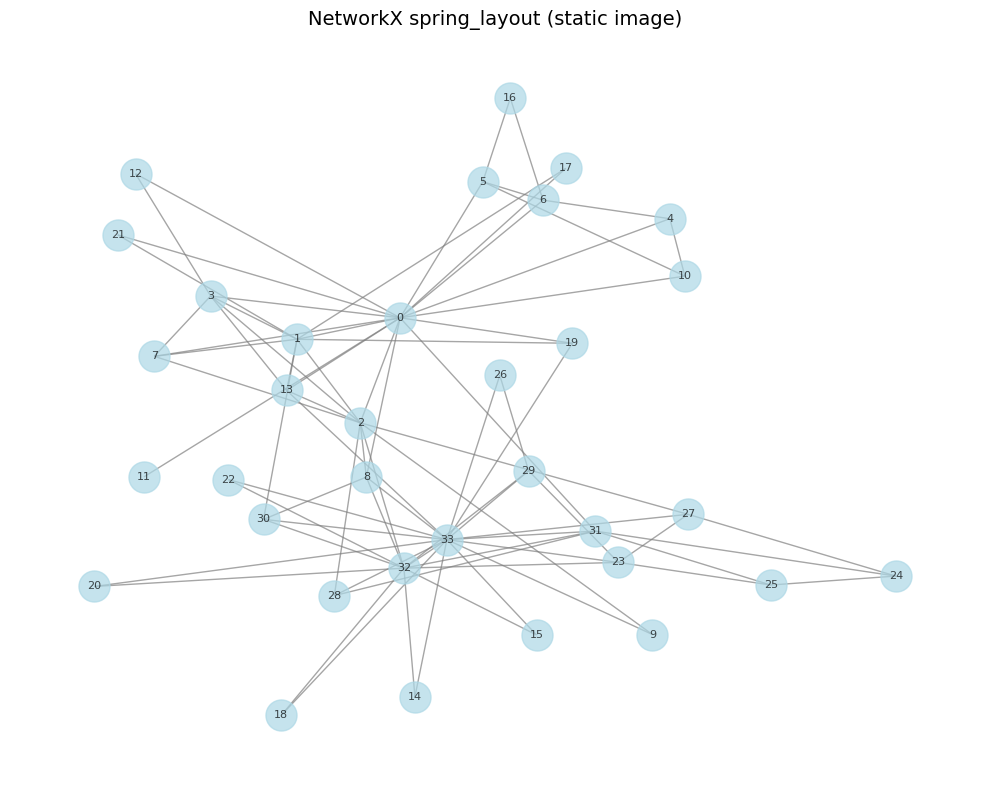

In [3]:
# Compute spring layout (same algorithm used by NodeSubstrates)
pos = nx.spring_layout(G, k=1.5, iterations=100, seed=42)

# Create figure
fig, ax = plt.subplots(figsize=(10, 8))

# Draw the network
nx.draw(G, pos, ax=ax,
        with_labels=True,
        node_color='lightblue',
        node_size=500,
        font_size=8,
        edge_color='gray',
        alpha=0.7)

ax.set_title('NetworkX spring_layout (static image)', fontsize=14)
plt.tight_layout()
plt.show()

## 3. NodeSubstrates Widget (Same Layout)

The widget uses the **same pre-computed layout** but adds interactivity:
- Click to select nodes
- Shift+drag to lasso select
- Drag free nodes to reposition them

In [4]:
# Create widget WITHOUT auto_substrate to compare layouts
widget_basic = NodeSubstratesWidget(G, auto_substrate=False)
widget_basic

## 4. NodeSubstrates with Auto-Detected Communities

With `auto_substrate=True`, the widget automatically detects communities based on
graph structure and node attributes, then creates a substrate for the highest-scoring region.

**Inside the substrate:**
- Nodes are positioned using dimensionality reduction (UMAP/PCA/t-SNE) on their attributes
- This reveals patterns not visible in the force-directed layout

In [5]:
# Create widget WITH auto_substrate
widget_auto = NodeSubstratesWidget(G, auto_substrate=True)
widget_auto

## 5. View Detected Communities

The widget identifies regions that would benefit from semantic substrate analysis.

In [6]:
for i, suggestion in enumerate(widget_auto.suggested_regions):
    print(f"\nCommunity {i + 1}: {suggestion['label']}")
    print(f"  Nodes: {len(suggestion['node_ids'])}")
    print(f"  Score: {suggestion['score']:.2f}")
    print(f"  Reason: {suggestion['reason']}")
    print(f"  Recommended DR: {suggestion['recommended_dr']}")


Community 1: Community 3
  Nodes: 13
  Score: 0.63
  Reason: 13 nodes with high attribute diversity, potential outliers among neighbors
  Recommended DR: pca

Community 2: Community 1
  Nodes: 17
  Score: 0.62
  Reason: 17 nodes with high attribute diversity, potential outliers among neighbors
  Recommended DR: umap


## 6. Create Multiple Substrates

You can create additional substrates from the suggestions to compare different communities.

In [7]:
# Accept the second suggestion if available
if len(widget_auto.suggested_regions) > 1:
    substrate_id = widget_auto.accept_suggestion(1)
    print(f"Created second substrate: {substrate_id}")
    print(f"\nNow showing {len(widget_auto.substrates)} substrates")

/home/christinoleo/Projects/papers/nodeSubstrates/implementation/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Created second substrate: substrate_1

Now showing 2 substrates


## Summary

**NodeSubstrates provides:**

1. **Preserved Layout** - Uses the same force-directed algorithm as NetworkX
2. **Interactivity** - Select, drag, and explore nodes directly
3. **Semantic Substrates** - Focus on communities using dimensionality reduction
4. **Edge Coloring** - Distinguish between topological (blue), intra-substrate (orange), and inter-substrate (purple) connections
5. **Auto-Detection** - Automatically identify interesting regions based on structure and attributes